## 1. Introduction
This project investigates the motion of a simple pendulum using mathematical modelling and numerical simulation. The project begins with an idealised pendulum and progressively introduces damping to investigate its effect on the motion.

## 2. Assumptions
- The string suspending the pendulum has zero mass
- The pendulum is modelled as a point mass
- The length of the string is constant. It doesn't stretch go slack
- The gravitational field is uniform, so the gravitational acceleration $g$ is constant.
- The pivot point is fixed
- There is no friction between the pivot and the string

## 3. Equation of Motion for a Simple Pendulum ( no damping )
First, I will model an idealised pendulum. This neglects air resistance and other resistive forces.
By considering the tangential direction of the pendulum's motion, we define $ F $ to be the net force acting tangential to the pendulum, and $ \theta $ to be the angular displacement from the pendulum's equilibrium position, measured in radians. ($ \theta > 0 $ represents a clockwise angle, and $ \theta < 0 $ represents an anticlockwise angle) $ g $ is gravitational acceleration, $ m $ is the mass of the pendulum, and $ L $ is the length of the string.

Gravitational force is given by

$ F = mg $

The component of gravitational force acting tangetially to the pendulum has magnitude

$ mg\sin(\theta) $

For a positive angular displacement, the tangential component of gravity
acts in the opposite direction to the displacement. Therefore,

$ F_{tan} = -mg\sin(\theta) $

To get an expression for $ F $ in terms of $ \theta $ we consider the relationship between arc length and angular displacement

$ s = L\theta $

where $ s $ denotes arc length in the clockwise direction, and $ a $ represents the acceleration tangential to the pendulum.
Then by differentiating twice, we get

$ \ddot{s} = L \ddot{\theta} $

$ a_{tan} = L \ddot{\theta} $

By applying Newton's Second Law in the tangential direction,

$ F_{tan} = m a_{tan} $

Therefore, $ F = mL \ddot{\theta} $

Substituting the expressions for the tangential force and acceleration,

$ mL \ddot{\theta} = -mg\sin(\theta) $

This is the equation of motion of a simple pendulum

$$\boxed{ \ddot{\theta} = -\frac{g}{L}\sin(\theta) }$$

### 3.1 Small Angle Approximation

For small values of $ \theta $ , $ \sin(\theta) $ can be approximated with $ \theta $, and the equation now looks like this

$ \ddot{\theta} = -\frac{g}{L}\theta $

This equatiopn

This equation has the same form as the equation of simple harmonic motion,

$ \ddot{x} + k^2x = 0. $

The general solution to this second order linear ODE is

$ x = A\sin(k t) + B\cos(k t) $
for some constants $ A $, $ B $, depending on the initial conditions.

Therefore, for small angular displacements, the motion of a simple
pendulum can be approximated as simple harmonic motion with

$ k = \sqrt{\frac{g}{L}}.$

and has general solution
$ \theta = A\sin(\sqrt{\frac{g}{L}} t) + B\cos(\sqrt{\frac{g}{L}} t) $


In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)

coefficients = np.array([
    [1, 0],
    [0, np.sqrt(g / L)]
])

initial_conditions = np.array([
    theta_0,
    omega_0
])

x = np.linalg.solve(coefficients, initial_conditions)
A = x[0]
B = x[1]

print("A is:", A)
print("B is:", B)

t=np.linspace(0, 10, 1000)  # time array from 0 to 10 seconds

A is: 0.5235987755982988
B is: 0.0


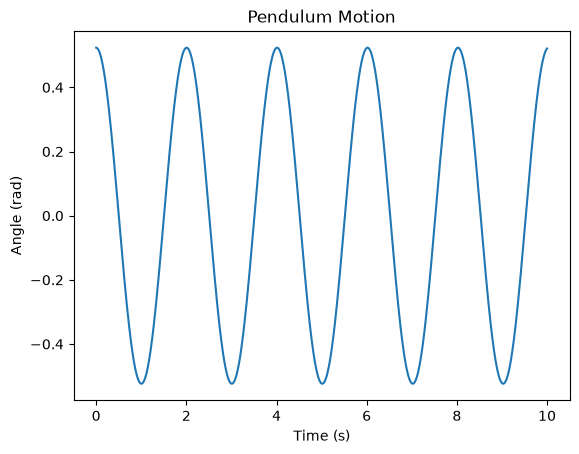

In [50]:
plt.plot(t, A * np.cos(np.sqrt(g / L) * t) + B * np.sin(np.sqrt(g / L) * t))
plt.title("Pendulum Motion")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.show()


## 4. Numerical Method
$$ \boxed{ \ddot{\theta} = -\frac{g}{L}\sin(\theta) }$$
For larger values of $ \sin{\theta} $, $ \sin{\theta} $ cannot be approxiamted with $ \theta $. However, this ODE has no closed form solution,as it is a non-linear ODE due to the sine function. 
So, we will implement a numerical method to solve this ODE as it is easy to estimate its path

### 4.1 Euler's Method
The pendulum has to be rewritten as two first-order differential equations, one in terms of angular displacement, and one in terms of angular velocity. Let angular velocity be denoted by $ \omega $.

$ \omega  = \dot{\theta} $ and
$ \dot{\omega} = \ddot{\theta} $

We now have $ \dot{\omega} = -\frac{g}{L}\sin(\theta) $

Using Euler's Method, we have that
$$ \theta_{n+1} = \theta_{n} + \Delta t (\omega_{n}) $$

$$ \omega_{n+1} = \omega_{n} + \Delta t (\ddot{\theta_{n}}) $$
$$ \omega_{n+1} = \omega_{n} + \Delta t (-\frac{g}{L}\sin(\theta_{n})) $$

This creates an interative process using known values of $ \omega $ and $ \theta $ to estimate their next respective values, where $ \Delta t $ represents a small change in time, the difference in time between successive measurements of $ \omega $ and $ \theta $. The smaller the value of $ \Delta t $ the more accurate the estimates are.

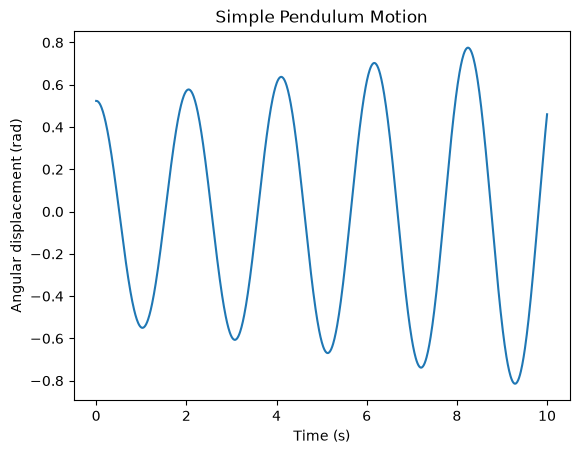

In [51]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
t_max = 1000 # number of time steps

t = np.linspace(0, 10, t_max)  # time array from 0 to 10 seconds with t_max points
dt = t[1] - t[0]  # time step size 

theta = np.zeros(len(t))    # array to store angular displacement values
omega = np.zeros(len(t))    # array to store angular velocity values

theta[0] = theta_0 
omega[0] = omega_0  

for n in range(len(t) - 1):
    theta[n + 1] = theta[n] + omega[n] * dt
    omega[n + 1] = omega[n] - (g / L) * np.sin(theta[n]) * dt

# Plotting the results  
plt.plot(t, theta) 

plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion")

plt.show()

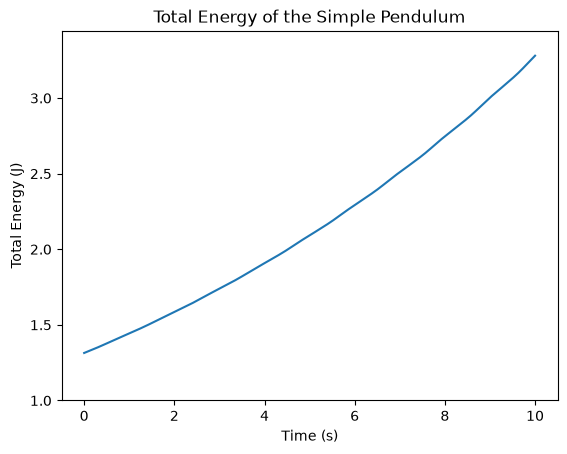

In [52]:
# Checking the energy of the pendulum
# Calculating the kinetic and potential energy
KE = 0.5 * (L**2) * (omega**2)
PE = g * L * (1 - np.cos(theta))
# Total energy
E_total = KE + PE

plt.plot(t, E_total)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy of the Simple Pendulum")
plt.ylim(1, np.max(E_total) * 1.05)  # Set y-axis limits for better visualization
plt.show()

### 4.2 Increase in Total Energy

The graph of the simple pendulum in an ideal setting should follow a sine wave, however, using Euler's Method, it seems to create a wave with amplitude increasing over time, and so does the total energy of the system. 
This is because Total Energy = Kinetic Energy + Potential Energy which is equal to 
$ \frac{1}{2} m v^2 + m g h  $

Similar to the method of expressing $ F_{tan} $ in terms of $ \theta $, we start with

$ s = L\theta $

where $ s $ denotes arc length in the clockwise direction, and $ a $ represents the acceleration tangential to the pendulum.
Then by differentiating once, we get

$ \dot{s} = L \dot{\theta} $

$ v = L \omega $

The Kinetic Energy of the system, $ K $ is represented as 
$$ K = \frac{1}{2} m {L \omega }^2 = \frac{1}{2} m {L}^2 {\omega}^2 $$

Therefore, the Total Energy is equal to $$ \frac{1}{2} m {L}^2 {\omega}^2  + m g h $$

The only variables being manipulated is $ \theta $ and $ \omega $ so seems to be that an overestimation of $ \omega $ could be leading to an increase in energy over time.

Eulers' Method says that $ \theta_{n+1} = \theta_n + \omega_n \Delta t $, which assumes that $ \omega_n $ stays constant in this $ \Delta t $  interval. However, $ \omega $ is continuosly changing because $ \dot{\omega}  = -\frac{g}{L}\sin(\theta) $. If $ \omega $ were to be constant, $ \dot{\omega} $ should be equal to 0, which it isn't. This explains why the amnplitude of the waves seems to be increasing, and consequently the total energy. 

### 4.3 Why choosing a smaller $ \Delta t $ makes for a better approximation 

Taylor Series of a function at some real number,$ a $

$$ f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a) + ... = \sum_{n=0}^{\infty} \frac{f^n(a)}{n!}(x-a)^n$$

Let $ x = t + \Delta t $ and evaluate at $ a = t $. Then,
$$ \theta(t + \Delta t) = \theta(t) + \dot{\theta}(t)(\Delta t) +\frac{\ddot{\theta}(t)}{2!}(\Delta t)^2  + ... $$

Euler's Method says that $$ \theta(t + \Delta t) \approx \theta(t) + \dot{\theta}(t)(\Delta t) $$
This leaves out the terms behind which are proportional to powers of $ \Delta t $. The error is $ \frac{\ddot{\theta}(t)}{2!}(\Delta t)^2  + ...  $

Therefore, by choosing smaller values of $ \Delta t $, the error gets smaller.

________________________________________________________________________________________________________________________________________________

 Note: Taylor Series requires that $ \theta (t) $ is infinitely differentiable. It is because of the relationship 

$ \ddot{\theta} = -\frac{g}{L}\sin(\theta) $

$ \theta''(t) = -\frac{g}{L}\sin(\theta(t)) $

$ \theta $ is continuous, and $ \ddot{\theta} $ is continuous because sine and $ \theta $ are continuos. So $ \theta $ is at least twice differentiable.
Notice that the right hand side is differentiable, so

$ \theta^{(3)} (t)=  -\frac{g}{L}\cos(\theta(t)) \theta'(t) $
and in general $ \theta^{(n)}(t) $ exists for all $ n $ because sin and cos are infinitely differentiable, along with the lower derivatives already establised to exist.


## 5. A Damped Pendulum
In this section, we will investigate the model for two types of damping. Linear, and quadratic damping. In this model, it is assumed that the damping is due only to drag/ air resistance, and opposes the pendulum's motion. Hence, it is a force that acts tangential but opposite to the motion of the pendulum.
An object moving through a fluid (liquid or gase, in this case it is the latter) can experience drag from different physical effects. 
Reynolds Number is a quantity used in fluid dynamics that predicts fluid flow patterns.

$ Re = \frac{\rho u L}{\mu } $.

This measures the ratio between _inertial_ and _viscous_ forces.
At low Reynolds numbers, viscous effects are more significant. Viscosity is resistance force of a fluid when there is relative motion between volumes of fluid. In layman's terms, this is akin to "thickness" in a fluid. Here,  drag force is modelled to be proportional to the velocity of the object,

$$
F_d \propto v.
$$

At higher Reynolds numbers, inertial effects are more significant. These arise from the inertia of the fluid as it is accelerated and displaced by the moving object. Here, the drag force is modelled to be proportional to the square of the velocity,

$$
F_d \propto v^2.
$$

Therefore, the linear and quadratic damping models represent different approximations of the physical mechanisms responsible for drag. The linear model is associated with drag dominated by viscous effects, while the quadratic model is associated with drag where inertial effects are more significant.


### 5.1 Linear Damping 
The drag force, $ F_d $ is assumed to be proportional to velocity. $$ F_d = bv $$ where $ b $ is a positive constant called a _damping coefficient_, and $ v $ is the tangential velocity of the pendulum.

From section 4.2, we have

$ s = L\theta $

$ \dot{s} = L \dot{\theta} $

$ v = L \omega $
Since drag force acts opposite in direction to the direction of motion, $$ F_d = -b L \omega = -bL\dot{\theta} $$ 

In the idealised case, $$ mL \ddot{\theta} = -mg\sin(\theta) $$
When introducing the damping factor, $$ \boxed{ mL \ddot{\theta} = -mg\sin(\theta) - bL\dot{\theta} }$$ 

Again, by taking
$ \omega  = \dot{\theta} $ and
$ \dot{\omega} = \ddot{\theta} $

$$ \boxed{ mL \dot{\omega} = -mg\sin(\theta) - bL\omega } $$

We now have $$ \ddot{\theta}_n = \dot{\omega}_n = -\frac{g}{L}\sin(\theta_{n}) -\frac{b}{m}\omega_n $$

Using Euler's Method, we have that
$$ \theta_{n+1} = \theta_{n} + \Delta t (\omega_{n}) $$

$$ \omega_{n+1} = \omega_{n} + \Delta t (\ddot{\theta}_n) $$
$$ \omega_{n+1} = \omega_{n} + \Delta t (-\frac{g}{L}\sin(\theta_{n}) -\frac{b}{m}\omega_n) $$



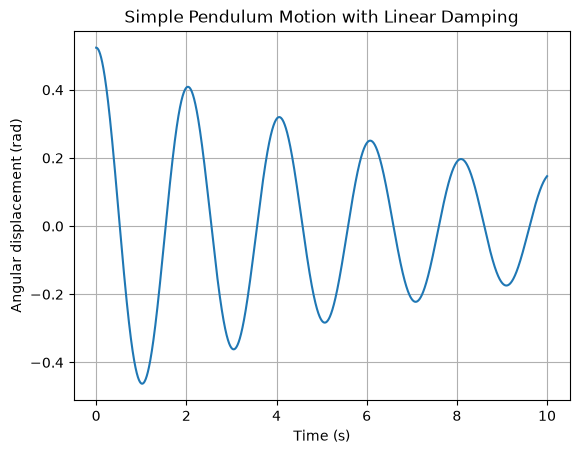

In [53]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)
b= 0.25  # damping coefficient (kg/s)
m= 1.0  # mass of the pendulum bob (kg)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
t_max = 10000  # number of time steps

t = np.linspace(0, 10, t_max)  # time array from 0 to 10 seconds with t_max points
dt = t[1] - t[0]  # time step size 

theta = np.zeros(len(t))    # array to store angular displacement values
omega = np.zeros(len(t))    # array to store angular velocity values

theta[0] = theta_0 
omega[0] = omega_0  

for n in range(len(t) - 1):
    theta[n + 1] = theta[n] + omega[n] * dt
    omega[n + 1] = omega[n] + dt * (-(g / L) * np.sin(theta[n]) - (b/m) * omega[n])

# Plotting the results  
plt.plot(t, theta) 

plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion with Linear Damping")
plt.grid()
plt.show()

### 5.2 Small Angle Approximation
For small values of $ \theta $ , $ \sin(\theta) $ can be approximated with $ \theta $. $ \sin(\theta) \approx \theta $.

Therefore, the new equation of motion is
$$  mL \ddot{\theta} = -mg\theta - bL\dot{\theta}  $$
$$ \ddot{\theta} + \frac{b}{m}\dot{\theta} + \frac{g}{L}\theta = 0 $$
This is a homogeneous second-order linear differential equation, which has a characteristic equation
$$ \lambda^2 + \frac{b}{m}\lambda + \frac{g}{L} = 0 $$
which has roots $ \lambda_1 = -\frac{b}{2m} + \frac{1}{2} \sqrt{ \frac{b^2}{m^2} - \frac{4g}{L}} $, $ \lambda_2 = -\frac{b}{2m} - \frac{1}{2} \sqrt{ \frac{b^2}{m^2} - \frac{4g}{L}} $

#### 5.2.1 Overdamping 
If $ \frac{b^2}{m^2} - \frac{4g}{L} > 0 $, the pendulum system is _overdamped_. The characteristic equation has two real and distinct roots. This is the general solution to the differential equation, with constants $ c_1 $, $ c_2 $ depending on initial conditions: 
$$ \theta(t) = c_1 e^{\lambda_1 t} + c_2 e^{\lambda_2 t} $$
Here, $ \lambda_1 $, $ \lambda_2 < 0 $, so $\theta$ approaches zero as time increases, but doesn't reach it as the exponential components have horizontal asymptotes at 0. 

#### 5.2.2 Critical Damping
If $ \frac{b^2}{m^2} - \frac{4g}{L} = 0 $, the pendulum system is _critically damped_. The characteristic equation has two equal, real roots, $\lambda_c $.  This is the general solution to the differential equation:
$$ \theta(t) = c_1 e^{\lambda_c t} + c_2 t e^{\lambda_c t} $$
Similar to overdamping, $ \lambda_1 $, $ \lambda_2 < 0 $, so $\theta$ approaches zero as time increases, but doesn't reach it as the exponential components have horizontal asymptotes at 0. However, critical damping does approach 0 faster than overdamping does. This is because $\lambda_c < \lambda_1 < 0 $.
So,  $0< e^{\lambda_c t} < e^{\lambda_1 t} $. The exponent containing $\lambda_c t $ will approach 0 faster than the exponent containing $ \lambda_1 t $

#### 5.2.3 Underdamping
If $ \frac{b^2}{m^2} - \frac{4g}{L} < 0 $, the pendulum system is _under damped_. The characteristic equation has two complex roots. This is the general solution to the differential equation:
$$ \theta(t) = c_1 e^{\alpha t} \cos(\beta t) + c_2 e^{\alpha t} \sin(\beta t) = e^{\alpha t} (c_1 \cos(\beta t) + c_2 \sin(\beta t))$$
where $ \alpha = Re(\lambda_1)=-\frac{b}{2m}, \beta = Im(\lambda_1)= \frac{1}{2} \sqrt{ |\frac{b^2}{m^2} - \frac{4g}{L}|}$
This has the same form as the general solution to the idealised pendulum in Section 3.1, just with an added scalar of $e^{\alpha t}$, which is called the _damping factor_. $ e^{\alpha t} $ decays over time, causing the amplitudes of the oscillations to decrease over time. $ e^{\alpha t} = e^{-\frac{b}{2m} t} $, which tells us that the greater the damping coefficient the faster the decay of the oscillations.

c_1 is: 0.5235987755982988
c_2 is: 0.0209131894329786


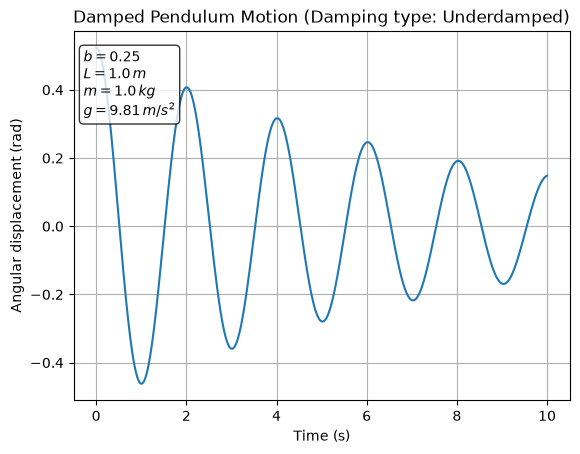

In [54]:
R = -b / (2 * L)
D  = b**2 / (4 * L**2) - g / L

t=np.linspace(0, 10, 1000)  # time array from 0 to 10 seconds

if D > 0:
    coefficients = np.array([
    [1, 1],
    [(R+np.sqrt(D)), R-np.sqrt(D)]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)
    

    plt.plot(t, c_1 * np.exp((R + np.sqrt(D)) * t) + c_2 * np.exp((R - np.sqrt(D)) * t))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Damping type: Overdamped)")

    plt.show()
elif D == 0:
    coefficients = np.array([
    [1, 0],
    [R, 1]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)

    plt.plot(t, (c_1 + c_2 * t) * np.exp(R * t))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Damping type: Critically Damped)")

    plt.show()
else: 
    coefficients = np.array([
    [1, 0],
    [R, np.sqrt(-D)]
    ])

    initial_conditions = np.array([
    theta_0,
    omega_0
    ])

    x = np.linalg.solve(coefficients, initial_conditions)
    c_1 = x[0]
    c_2 = x[1]

    print("c_1 is:", c_1)
    print("c_2 is:", c_2)

    plt.plot(t, np.exp(R * t) * (c_1 * np.cos(np.sqrt(-D) * t) + c_2 * np.sin(np.sqrt(-D) * t)))

    plt.xlabel("Time (s)") 
    plt.ylabel("Angular displacement (rad)")
    plt.title("Damped Pendulum Motion (Damping type: Underdamped)")
    plt.text(
    0.02, 0.95,
    f"$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
    plt.grid()
    plt.show()

### 5.3 Quadratic Damping
The drag force, $ F_d $ is assumed to be proportional to velocity. $$ F_d = kv^2 $$ where $ k $ is a positive constant called a _damping coefficient_, and $ v $ is the tangential velocity of the pendulum.

Similar to Linear Damping, from section 4.2, we have

$ s = L\theta $

$ \dot{s} = L \dot{\theta} $

$ v = L \omega $

Hence, $$ F_d = k L^2 \omega^2 = kL^2(\dot{\theta})^2 $$ 

Note that this force is always positive since $ k, L > 0 $ and $ (\dot{\theta})^2 ≥ 0 $. However, drag always acts in the opposite direction to the direction of motion, so it must be signed. Therefore, the force will be rewritten as 
$$ F_d = - kL^2 \dot{\theta} |\dot{\theta}| $$
This makes it so that $ F_d $ is negative for positive $ \dot{\theta} $ and positive for negative $ \dot{\theta} $
In the idealised case, $$ mL \ddot{\theta} = -mg\sin(\theta) $$
When introducing the damping factor, $$ \boxed{ mL \ddot{\theta} = -mg\sin(\theta)  - kL^2 \dot{\theta} |\dot{\theta}| }$$ 

Again, by taking
$ \omega  = \dot{\theta} $ and
$ \dot{\omega} = \ddot{\theta} $

$$ \boxed{ mL \dot{\omega} = -mg\sin(\theta) - kL^2\omega |\omega| } $$

We now have $$ \ddot{\theta}_n = \dot{\omega}_n = -\frac{g}{L}\sin(\theta_{n}) -\frac{kL}{m}\omega_n |\omega_n |$$

Using Euler's Method, we have that
$$ \theta_{n+1} = \theta_{n} + \Delta t (\omega_{n}) $$

$$ \omega_{n+1} = \omega_{n} + \Delta t (\ddot{\theta}_n) $$
$$ \omega_{n+1} = \omega_{n} + \Delta t (-\frac{g}{L}\sin(\theta_{n}) -\frac{kL}{m}\omega_n |\omega_n |) $$

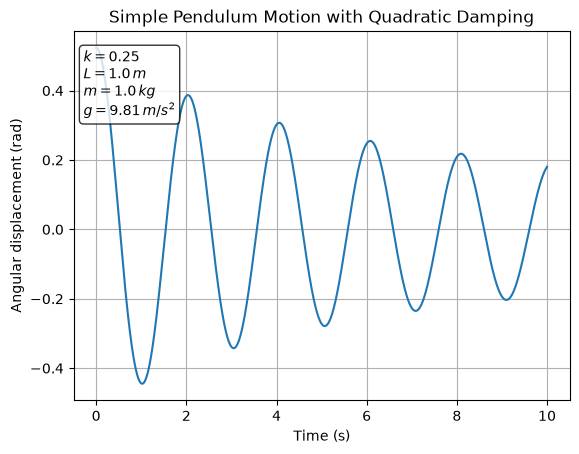

In [55]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)
k= 0.25  # damping coefficient (kg/s)
m= 1.0  # mass of the pendulum bob (kg)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
t_max = 100000  # number of time steps

t = np.linspace(0, 10, t_max)  # time array from 0 to 10 seconds with t_max points
dt = t[1] - t[0]  # time step size 

theta = np.zeros(len(t))    # array to store angular displacement values
omega = np.zeros(len(t))    # array to store angular velocity values

theta[0] = theta_0 
omega[0] = omega_0  

for n in range(len(t) - 1):
    theta[n + 1] = theta[n] + omega[n] * dt
    omega[n + 1] = omega[n] + dt * (-(g / L) * np.sin(theta[n]) - (k * L / m) * omega[n] * abs(omega[n]))

# Plotting the results  
plt.plot(t, theta) 

plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion with Quadratic Damping")
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.grid()
plt.show()

### 5.4 Comparison of Damping Models
Let's put both scenarios together for comparison.

#### 5.4.1 Angular Displacement against Time

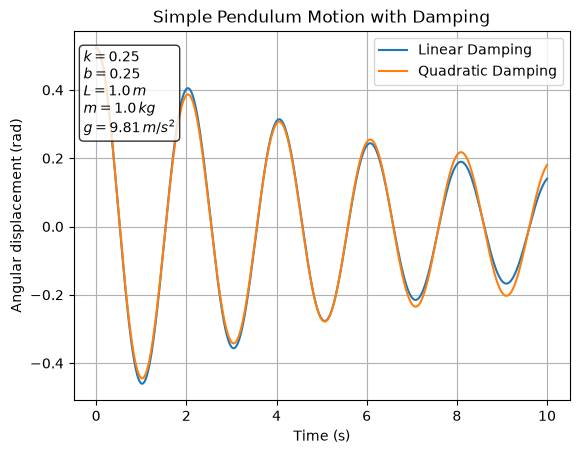

In [56]:
L = 1.0   # length of the pendulum (m)
g = 9.81  # acceleration due to gravity (m/s^2)
k= 0.25  # damping coefficient for quadratic damping (kg/s)
b= 0.25  # damping coefficient for linear damping (kg/s)
m= 1.0  # mass of the pendulum bob (kg)

theta_0 = np.radians(30)  # initial angle (30 degrees converted to radians)
omega_0 = 0.0  # initial angular velocity (rad/s)
step_number = 300000  # number of time steps

t = np.linspace(0, 10, step_number)  # time array from 0 to 10 seconds with step_number points
dt = t[1] - t[0]  # time step size 

# Simulating the pendulum motion with linear damping
theta_1 = np.zeros(len(t))    # array to store angular displacement values
omega_1 = np.zeros(len(t))    # array to store angular velocity values

theta_1[0] = theta_0 
omega_1[0] = omega_0  

for n in range(len(t) - 1):
    theta_1[n + 1] = theta_1[n] + omega_1[n] * dt
    omega_1[n + 1] = omega_1[n] + dt * (-(g / L) * np.sin(theta_1[n]) - (b/m) * omega_1[n])

# Simulating the pendulum motion with quadratic damping
theta_2 = np.zeros(len(t))    # array to store angular displacement values 
omega_2 = np.zeros(len(t))    # array to store angular velocity values

theta_2[0] = theta_0 
omega_2[0] = omega_0  

for n in range(len(t) - 1):
    theta_2[n + 1] = theta_2[n] + omega_2[n] * dt
    omega_2[n + 1] = omega_2[n] + dt * (-(g / L) * np.sin(theta_2[n]) - (k * L / m) * omega_2[n] * abs(omega_2[n]))

# Plotting the results  
plt.plot(t, theta_1, label="Linear Damping")
plt.plot(t, theta_2, label="Quadratic Damping")
plt.legend()
plt.xlabel("Time (s)") 
plt.ylabel("Angular displacement (rad)")
plt.title("Simple Pendulum Motion with Damping")
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.grid()
plt.show()

Both types of damping look very similar for the values of $k$ ,$b$ ,$L$, $m$ , $\theta_0$ and $\omega_0 $ that I have chosen. 


#### 5.4.2 Angular Velocity against Time

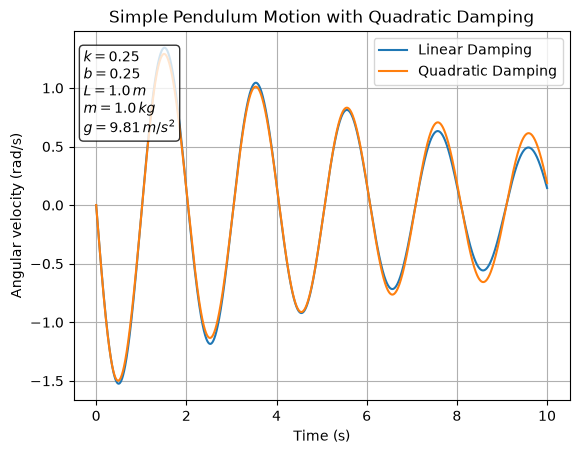

In [57]:
plt.plot(t, omega_1, label="Linear Damping")
plt.plot(t, omega_2, label="Quadratic Damping")
plt.legend()
plt.xlabel("Time (s)") 
plt.ylabel("Angular velocity (rad/s)")
plt.title("Simple Pendulum Motion with Quadratic Damping")
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.grid()
plt.show()

Once again, not much difference, however there is more difference as t gets larger. This relationship is significant because $ |F_d| \propto |\omega| $ for linear damping and $ |F_d| \propto |\omega|^2 $ for quadratic damping, Hence, damping force should decrease more signifincantly for quadratic damping when $ \omega $ decreases, and this is observed in the graph as the decrease in the amplitude of the waves is more prominent in the graph of linear damping.

#### 5.4.3 Damping Force against Time

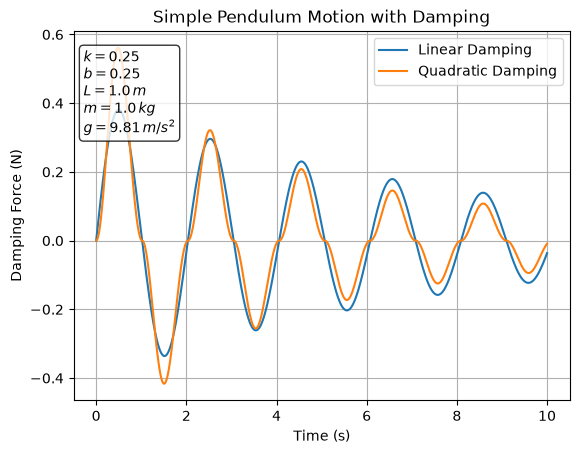

In [58]:
F_1 = -b * L * omega_1 
F_2 = -k * L**2 * omega_2 * abs(omega_2)
plt.plot(t, F_1, label="Linear Damping")
plt.plot(t, F_2, label="Quadratic Damping")
plt.legend()
plt.xlabel("Time (s)") 
plt.ylabel("Damping Force (N)")
plt.title("Simple Pendulum Motion with Damping")
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.grid()
plt.show()

This graph has an unusual flattening effect near $ F_d = 0 $. $ F_d = 0 $ corresponds to a turning point, $ \omega = 0 $. This is because for quadratic damping, the magnitude of the drag force, $F_q = kL^2 \omega^2 $. For linear damping, $  F_l = bL\omega $. As the pendulum reaches a turning point, $ \omega \to 0 $, $F_q$ approaches 0 faster than $ F_l $ because $F_q \propto \omega^2 $. $\omega ^2 $ approaches $0$ faster than $\omega $ does.

#### 5.4.4 Damping Force against Angular Velocity

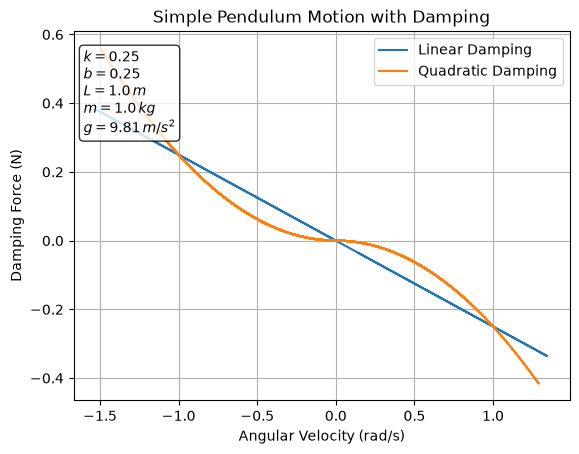

In [59]:
F_1 = -b * L * omega_1 
F_2 = -k * L**2 * omega_2 * abs(omega_2)
plt.plot(omega_1, F_1, label="Linear Damping")
plt.plot(omega_2, F_2, label="Quadratic Damping")
plt.legend()
plt.xlabel("Angular Velocity (rad/s)") 
plt.ylabel("Damping Force (N)")
plt.title("Simple Pendulum Motion with Damping")
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.grid()
plt.show()

Above it is discussed that $F_q \propto \omega^2 $ and $F_l \propto \omega$ and the shapes of the graphs are obvious here. Linear damping has a linear graph with respect to angular velocity whereas quadratic damping follows the shape of the equation $ y = x|x| $

#### 5.4.5 Energy against Time

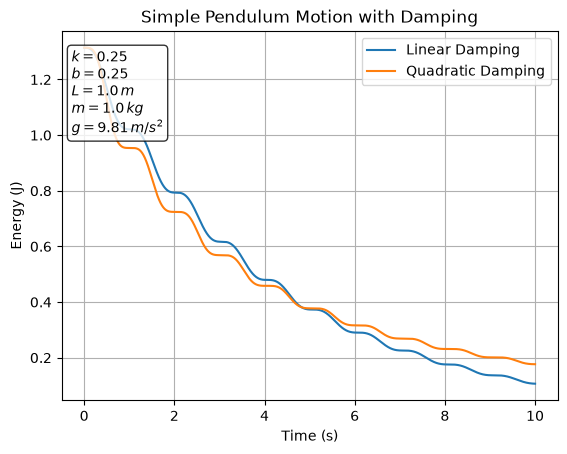

In [60]:
K_1 = 0.5 * m * (L**2) * (omega_1**2)
K_2 = 0.5 * m * (L**2) * (omega_2**2)
U_1 = m * g * L * (1 - np.cos(theta_1))
U_2 = m * g * L * (1 - np.cos(theta_2))
E_1 = K_1 + U_1
E_2 = K_2 + U_2
plt.plot(t, E_1, label="Linear Damping")
plt.plot(t, E_2, label="Quadratic Damping")
plt.legend()
plt.xlabel("Time (s)") 
plt.ylabel("Energy (J)")
plt.title("Simple Pendulum Motion with Damping")
plt.grid()
plt.text(
    0.02, 0.95,
    f"$k = {k}$\n$b = {b}$\n$L = {L}\\,m$\n$m = {m}\\,kg$\n$g = {g}\\,m/s^2$",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.show()

The graph has a periodic flattening effect, similar to the Damping Force - Time graph. 
The total energy of the system is $$ E = \frac{1}{2} m {L}^2 {\omega}^2  + m g L(1 - \cos{\theta})  $$

$$ \frac{dE}{dt} = mL^2 \omega \frac{d\omega}{dt} +mgL\sin{\theta}\frac{d\theta}{dt} $$

$$ \frac{dE}{dt} = mL^2 \omega \frac{d\omega}{dt} +mgL\omega\sin{\theta} $$

For linear damping, $ \frac{d\omega}{dt} = -\frac{g}{L}\sin{\theta} - \frac{b}{m}\omega $. Thus, $$ \frac{dE}{dt} = -bL^2\omega^2 $$
For quadratic damping, $ \frac{d\omega}{dt} = -\frac{g}{L}\sin{\theta} - \frac{kL}{m}\omega|\omega| $. Thus, $$ \frac{dE}{dt} = -kL^3|\omega|^3 $$ As $ \omega $ approaches $0$, both the energy time graphs should flatten out because as $\omega \to 0 $, $\frac{dE}{dt} \to 0$

### 5.5 Period 
A period is the interval of time between consecutive events. In this case, the period is the time taken for one complete oscillation. We can measure it as the time between peaks (high points) or troughs (low points) in the graph of angular displacement against time. 
For a simple pendulum, the period $ T $ is $$ T \approx 2 \pi \sqrt{ \frac{L}{g}} $$ provided that the amplitude, $\theta_{max}$ (maximum angular displacement) is small ($ \theta_{max}≤ 1 $ radian) 

In [61]:
# Find peaks in angular displacement for linear damping
peaks_1 = []

for n in range(1, len(theta_1) - 1):
    if theta_1[n] > theta_1[n-1] and theta_1[n] > theta_1[n+1]:
        peaks_1.append(n)

# Find peaks in angular displacement for quadratic damping
peaks_2 = []

for n in range(1, len(theta_2) - 1):
    if theta_2[n] > theta_2[n-1] and theta_2[n] > theta_2[n+1]:
        peaks_2.append(n)

periods_1 = np.diff(t[peaks_1])
periods_2 = np.diff(t[peaks_2])

average_period_1 = np.mean(periods_1)
average_period_2 = np.mean(periods_2)
theoretical_period = 2 * np.pi * np.sqrt(L / g)

print("Linear damping:", f"{average_period_1:.3f}")
print("Quadratic damping:", f"{average_period_2:.3f}")
print("Theoretical period:", f"{theoretical_period:.3f}")



Linear damping: 2.018
Quadratic damping: 2.018
Theoretical period: 2.006


Damping significantly reduces the amplitude and energy of the pendulum, but for the damping coefficients used in this simulation, it has little effect on the period.

## 6. Conclusion
The way in which damping affects the motion and energy of the pendulum was investigated. The effects of linear and quadratic damping are compared.

Damping from air resistance causes the pendulum to have smaller amplitudes of oscillations, while its period increases very slightly. Energy of the system decreases over time due to the damping. Linear damping depends on $ \omega $, while quadratic damping depends on $|\omega| \omega $. The difference in the two damping is most prominent when comparing angular displacement and angular velocity. However, in this model the differences are small. The loss of energy of the system slows down when $ \omega = 0 $

Euler's Method was used to simulate this system. However, it introduces numerical error, as seen in the undamped pendulum, when smaller time intervals are chosen. A better numerical method is using a high order of the Runge-Kutta Method. Euler's Method is sufficient as this system is simple and can be modelled with high accuracy when choosing a small time intervals

Different damping coefficients can be chosen to produce different results, with larger damping coefficients leading to more effective damping, causing the amplitude of the oscillations to decrease quicker. With larger initial angles, the path of the pendulum should largely remain unchanged but small angle approximations can no longer be used and the path of the pedulum may diverge from the path of a small angle approximation. This model uses a similar methodology to the models of more complex concepts, such as orbital mechanics and a two-body system, similarly involving differential equations and finding a numerical or analytical solution.